In [ ]:
import os
print(os.listdir())

['.config', 'sample_data']


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
!pip install mlxtend wordcloud --quiet

In [ ]:
#3 — Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from wordcloud import WordCloud
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, silhouette_score, davies_bouldin_score
)
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

print('All libraries imported successfully.')

All libraries imported successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Cell 4 — Load Data
import zipfile

# Get the uploaded zip file name
try:
    zip_file_name = next(iter(uploaded.keys()))
    print(f'Found uploaded file: {zip_file_name}')
except (NameError, StopIteration):
    zip_file_name = 'archive (1).zip'
    print(f'Using default: {zip_file_name}')

# Extract spam.csv from the zip
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extract('spam.csv')
    print('spam.csv extracted successfully!')

# Load into dataframe
df = pd.read_csv('spam.csv', encoding='latin-1', usecols=['v1', 'v2'])
df.columns = ['label', 'text']
print('Shape:', df.shape)
print(df['label'].value_counts())
df.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Found uploaded file: archive (1).zip
spam.csv extracted successfully!
Shape: (5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Cell 5 — Preprocessing
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

df['label_num']   = df['label'].map({'ham': 0, 'spam': 1})
df['char_count']  = df['text'].str.len()
df['word_count']  = df['text'].str.split().str.len()
df['upper_count'] = df['text'].str.count(r'[A-Z]')
df['digit_count'] = df['text'].str.count(r'\d')

print('Shape after cleaning:', df.shape)
print(df['label'].value_counts())
df[['label','char_count','word_count','upper_count','digit_count']].groupby('label').mean().round(2)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Shape after cleaning: (5169, 7)
label
ham     4516
spam     653
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,char_count,word_count,upper_count,digit_count
label,,,,
ham,70.46,14.13,3.83,0.29
spam,137.89,23.68,15.23,15.45


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# 6 — Statistical Description
for label in ['ham', 'spam']:
    data = df[df['label'] == label]['char_count']
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    print(f'[{label.upper()}]')
    print(f'  Mean     : {data.mean():.2f}')
    print(f'  Median   : {data.median():.2f}')
    print(f'  Mode     : {data.mode()[0]}')
    print(f'  Std Dev  : {data.std():.2f}')
    print(f'  Variance : {data.var():.2f}')
    print(f'  Range    : {data.min()} - {data.max()}')
    print(f'  IQR      : {q3 - q1:.2f}')
    print()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

[HAM]
  Mean     : 70.46
  Median   : 52.00
  Mode     : 22
  Std Dev  : 56.36
  Variance : 3176.25
  Range    : 2 - 910
  IQR      : 56.00

[SPAM]
  Mean     : 137.89
  Median   : 149.00
  Mode     : 159
  Std Dev  : 30.14
  Variance : 908.28
  Range    : 13 - 224
  IQR      : 25.00



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

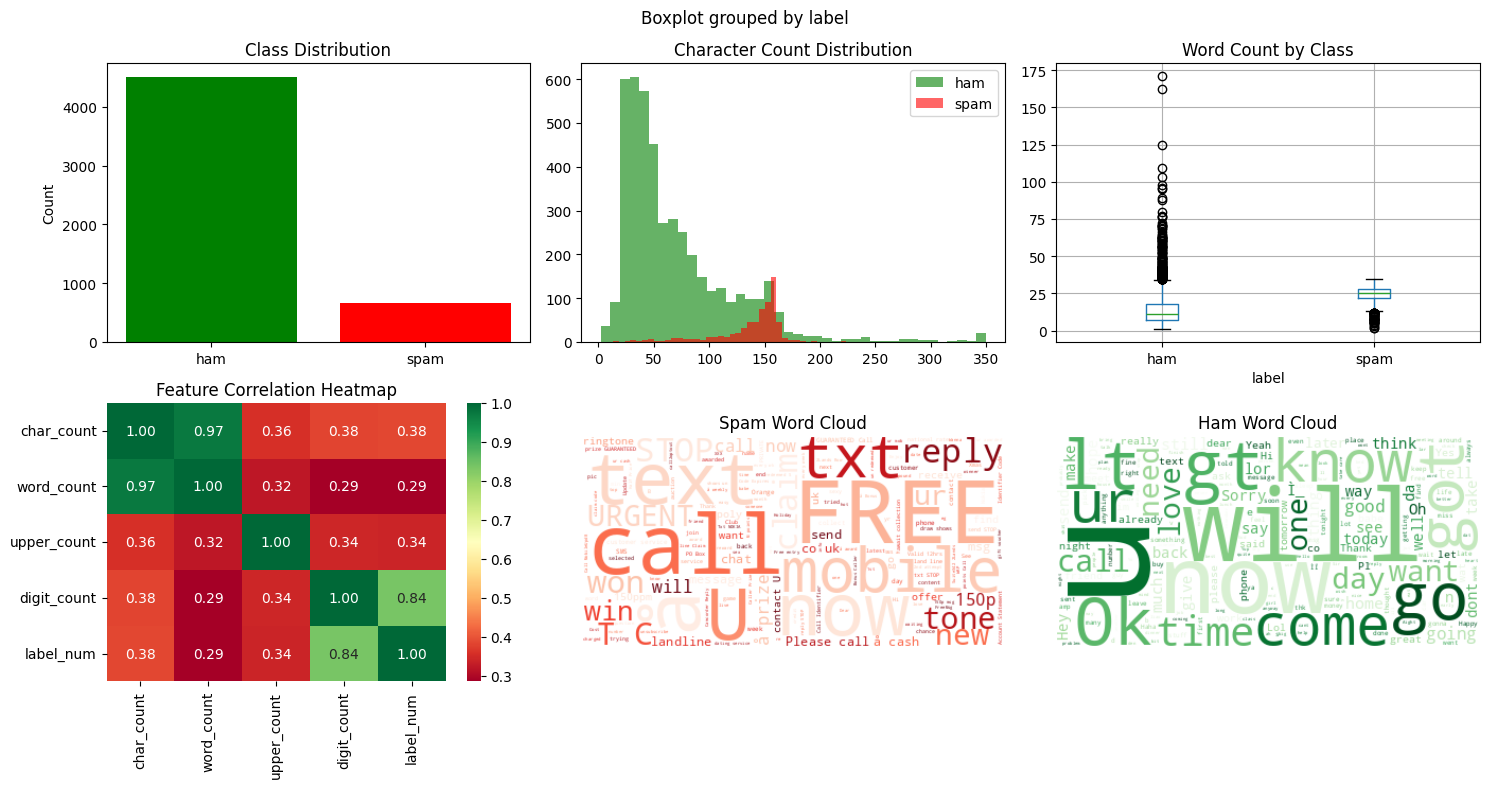

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# 7 — Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1. Class distribution
counts = df['label'].value_counts()
axes[0,0].bar(counts.index, counts.values, color=['green','red'])
axes[0,0].set_title('Class Distribution')
axes[0,0].set_ylabel('Count')

# 2. Char count histogram
for label, color in [('ham','green'), ('spam','red')]:
    axes[0,1].hist(df[df['label']==label]['char_count'].clip(0, 350),
                   bins=40, alpha=0.6, label=label, color=color)
axes[0,1].set_title('Character Count Distribution')
axes[0,1].legend()

# 3. Word count boxplot
df.boxplot(column='word_count', by='label', ax=axes[0,2])
axes[0,2].set_title('Word Count by Class')
plt.sca(axes[0,2])
plt.title('Word Count by Class')

# 4. Correlation heatmap
cols = ['char_count','word_count','upper_count','digit_count','label_num']
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1,0])
axes[1,0].set_title('Feature Correlation Heatmap')

# 5. Spam word cloud
wc1 = WordCloud(width=400, height=200, background_color='white', colormap='Reds').generate(
    ' '.join(df[df['label']=='spam']['text']))
axes[1,1].imshow(wc1, interpolation='bilinear')
axes[1,1].axis('off')
axes[1,1].set_title('Spam Word Cloud')

# 6. Ham word cloud
wc2 = WordCloud(width=400, height=200, background_color='white', colormap='Greens').generate(
    ' '.join(df[df['label']=='ham']['text']))
axes[1,2].imshow(wc2, interpolation='bilinear')
axes[1,2].axis('off')
axes[1,2].set_title('Ham Word Cloud')

plt.tight_layout()
plt.show()

In [ ]:
# 8 — Association Rules (Apriori)
stop = {'to','the','a','i','you','is','in','and','of','it','for',
        'my','your','on','at','are','be','this','that','have','me',
        'we','not','can','but','with','or','so','do','up'}

def clean_words(text):
    words = re.findall(r'\b[a-zA-Z]{3,}\b', text.lower())
    return list(set([w for w in words if w not in stop]))

spam_df = df[df['label'] == 'spam'].copy()
transactions = spam_df['text'].apply(clean_words).tolist()

all_words = [w for t in transactions for w in t]
top_words = [w for w, _ in Counter(all_words).most_common(50)]
transactions_filtered = [[w for w in t if w in top_words] for t in transactions]
transactions_filtered = [t for t in transactions_filtered if t]

te = TransactionEncoder()
basket_df = pd.DataFrame(te.fit_transform(transactions_filtered), columns=te.columns_)

freq_items = apriori(basket_df, min_support=0.08, use_colnames=True)
rules = association_rules(freq_items, metric='confidence', min_threshold=0.5)
rules = rules[rules['lift'] > 1.2].sort_values('lift', ascending=False)

print(f'Frequent itemsets : {len(freq_items)}')
print(f'Association rules : {len(rules)}')
rules[['antecedents','consequents','support','confidence','lift']].head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Frequent itemsets : 28
Association rules : 4


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
3,(prize),(call),0.092332,0.808219,1.818493
0,(claim),(call),0.104851,0.728261,1.638587
1,(from),(call),0.111111,0.612069,1.377155
2,(mobile),(call),0.084507,0.551020,1.239796


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# 9 — TF-IDF & Train/Test Split
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', 'url', text)
    text = re.sub(r'\d+', 'num', text)
    text = re.sub(r'[^\w\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

df['clean_text'] = df['text'].apply(preprocess_text)

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label_num'],
    test_size=0.2, random_state=42, stratify=df['label_num']
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Train size : {len(X_train)}')
print(f'Test size  : {len(X_test)}')
print(f'Features   : {X_train_tfidf.shape[1]}')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Train size : 4135
Test size  : 1034
Features   : 5000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# 10 — Train All Models
results = []

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred) * 100
    prec = precision_score(y_te, y_pred, zero_division=0) * 100
    rec  = recall_score(y_te, y_pred, zero_division=0) * 100
    f1   = f1_score(y_te, y_pred, zero_division=0) * 100
    cv   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='f1').mean() * 100
    cm   = confusion_matrix(y_te, y_pred)
    print(f'{name}: Acc={acc:.1f}% Prec={prec:.1f}% Rec={rec:.1f}% F1={f1:.1f}% CV_F1={cv:.1f}%')
    print(f'  CM -> TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}')
    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1': f1, 'CV_F1': cv, 'CM': cm}

results.append(evaluate_model('Naive Bayes',
    MultinomialNB(alpha=0.1),
    X_train_tfidf, X_test_tfidf, y_train, y_test))

results.append(evaluate_model('Decision Tree',
    DecisionTreeClassifier(criterion='gini', max_depth=20, min_samples_split=5, random_state=42),
    X_train_tfidf, X_test_tfidf, y_train, y_test))

best_k, best_score = 1, 0
for k in [1, 3, 5, 7, 11]:
    score = cross_val_score(
        KNeighborsClassifier(n_neighbors=k, metric='cosine'),
        X_train_tfidf, y_train, cv=3, scoring='f1').mean()
    if score > best_score:
        best_score, best_k = score, k
print(f'Best k for KNN: {best_k}')
results.append(evaluate_model(f'KNN (k={best_k})',
    KNeighborsClassifier(n_neighbors=best_k, metric='cosine'),
    X_train_tfidf, X_test_tfidf, y_train, y_test))

results.append(evaluate_model('SVM',
    LinearSVC(C=1.0, max_iter=2000, random_state=42),
    X_train_tfidf, X_test_tfidf, y_train, y_test))

results.append(evaluate_model('Random Forest',
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_tfidf, X_test_tfidf, y_train, y_test))

results.append(evaluate_model('AdaBoost',
    AdaBoostClassifier(n_estimators=100, learning_rate=1.0, algorithm='SAMME', random_state=42),
    X_train_tfidf, X_test_tfidf, y_train, y_test))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Naive Bayes: Acc=98.4% Prec=97.5% Rec=89.3% F1=93.2% CV_F1=94.3%
  CM -> TN=900  FP=3  FN=14  TP=117


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Decision Tree: Acc=97.3% Prec=95.6% Rec=82.4% F1=88.5% CV_F1=86.3%
  CM -> TN=898  FP=5  FN=23  TP=108


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

...

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

Random Forest: Acc=97.9% Prec=100.0% Rec=83.2% F1=90.8% CV_F1=90.3%
  CM -> TN=903  FP=0  FN=22  TP=109


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

AdaBoost: Acc=97.4% Prec=99.1% Rec=80.2% F1=88.6% CV_F1=86.2%
  CM -> TN=902  FP=1  FN=26  TP=105


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

               Accuracy  Precision  Recall     F1  CV_F1
Model                                                   
Naive Bayes       98.36      97.50   89.31  93.23  94.26
SVM               98.36      98.31   88.55  93.17  93.74
Random Forest     97.87     100.00   83.21  90.83  90.25
AdaBoost          97.39      99.06   80.15  88.61  86.18
Decision Tree     97.29      95.58   82.44  88.52  86.29
KNN (k=3)         97.20      98.11   79.39  87.76  90.79

Best Model: Naive Bayes (F1=93.23%)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

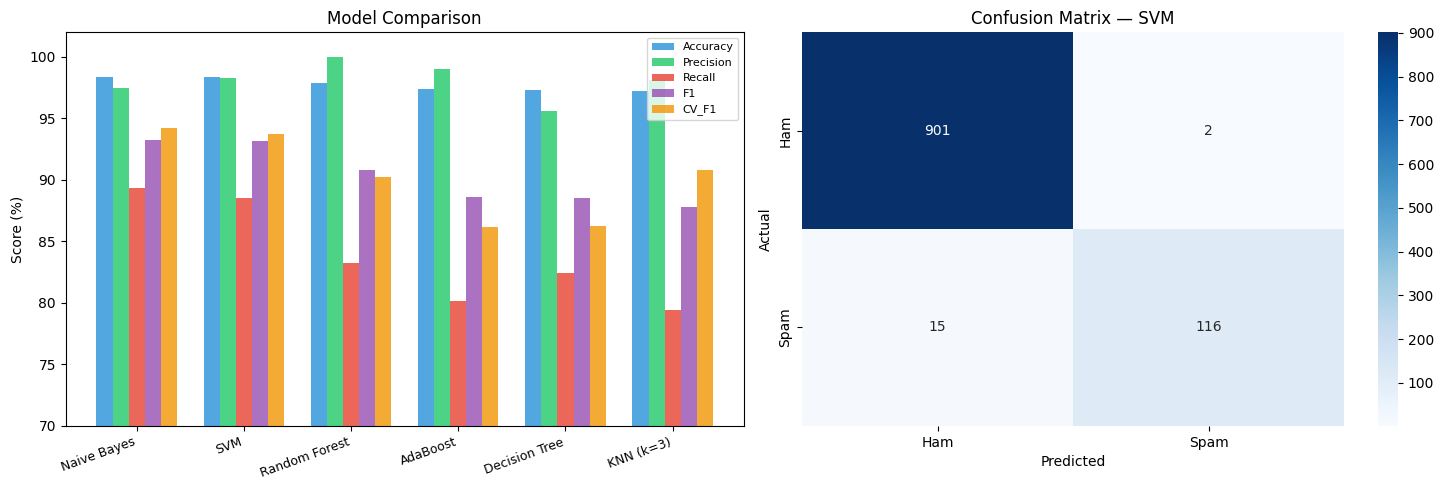

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# 11 — Model Comparison
summary = pd.DataFrame([{k: v for k, v in r.items() if k != 'CM'} for r in results])
summary = summary.set_index('Model').sort_values('F1', ascending=False)
best_model = summary['F1'].idxmax()
print(summary.round(2).to_string())
print(f'\nBest Model: {best_model} (F1={summary.loc[best_model, "F1"]:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

metrics = ['Accuracy','Precision','Recall','F1','CV_F1']
x = np.arange(len(summary))
width = 0.15
colors = ['#3498DB','#2ECC71','#E74C3C','#9B59B6','#F39C12']
for i, (m, c) in enumerate(zip(metrics, colors)):
    axes[0].bar(x + i*width, summary[m], width, label=m, color=c, alpha=0.85)
axes[0].set_xticks(x + width*2)
axes[0].set_xticklabels(summary.index, rotation=20, ha='right', fontsize=9)
axes[0].set_ylim(70, 102)
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Model Comparison')
axes[0].legend(fontsize=8)

svm_cm = next(r['CM'] for r in results if 'SVM' in r['Model'])
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
axes[1].set_title('Confusion Matrix — SVM')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

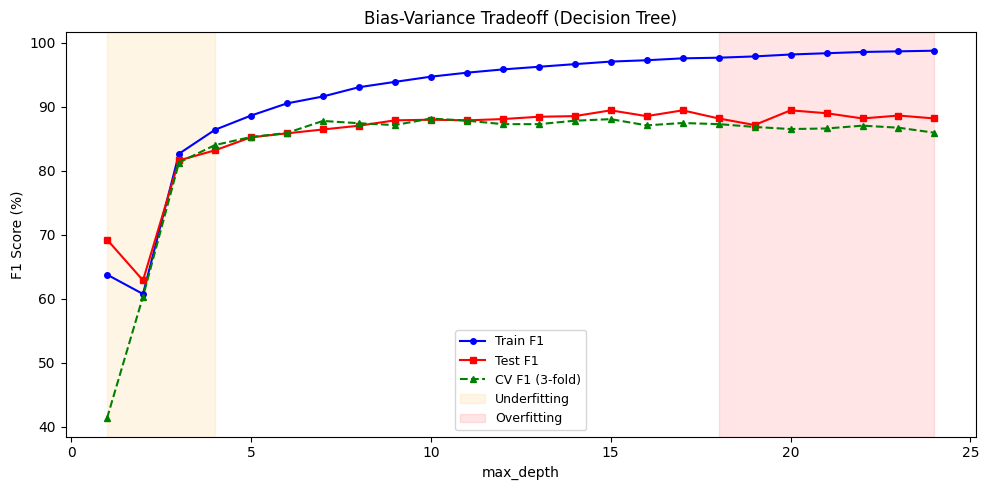

Best depth by test F1: 15 (F1=89.43%)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# 12 — Bias-Variance Tradeoff
depths = list(range(1, 25))
train_scores, test_scores, cv_scores = [], [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train_tfidf, y_train)
    train_scores.append(f1_score(y_train, clf.predict(X_train_tfidf)) * 100)
    test_scores.append(f1_score(y_test, clf.predict(X_test_tfidf)) * 100)
    cv_scores.append(cross_val_score(clf, X_train_tfidf, y_train, cv=3, scoring='f1').mean() * 100)

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, 'b-o', markersize=4, label='Train F1')
plt.plot(depths, test_scores,  'r-s', markersize=4, label='Test F1')
plt.plot(depths, cv_scores,    'g--^', markersize=4, label='CV F1 (3-fold)')
plt.axvspan(1, 4, alpha=0.1, color='orange', label='Underfitting')
plt.axvspan(18, 24, alpha=0.1, color='red', label='Overfitting')
plt.xlabel('max_depth')
plt.ylabel('F1 Score (%)')
plt.title('Bias-Variance Tradeoff (Decision Tree)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

best_depth = depths[test_scores.index(max(test_scores))]
print(f'Best depth by test F1: {best_depth} (F1={max(test_scores):.2f}%)')

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

K-Means  — Silhouette: 0.0501  Davies-Bouldin: 3.5766
Agglomerative — Silhouette: 0.0625
DBSCAN — Clusters: 1  Noise: 10


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

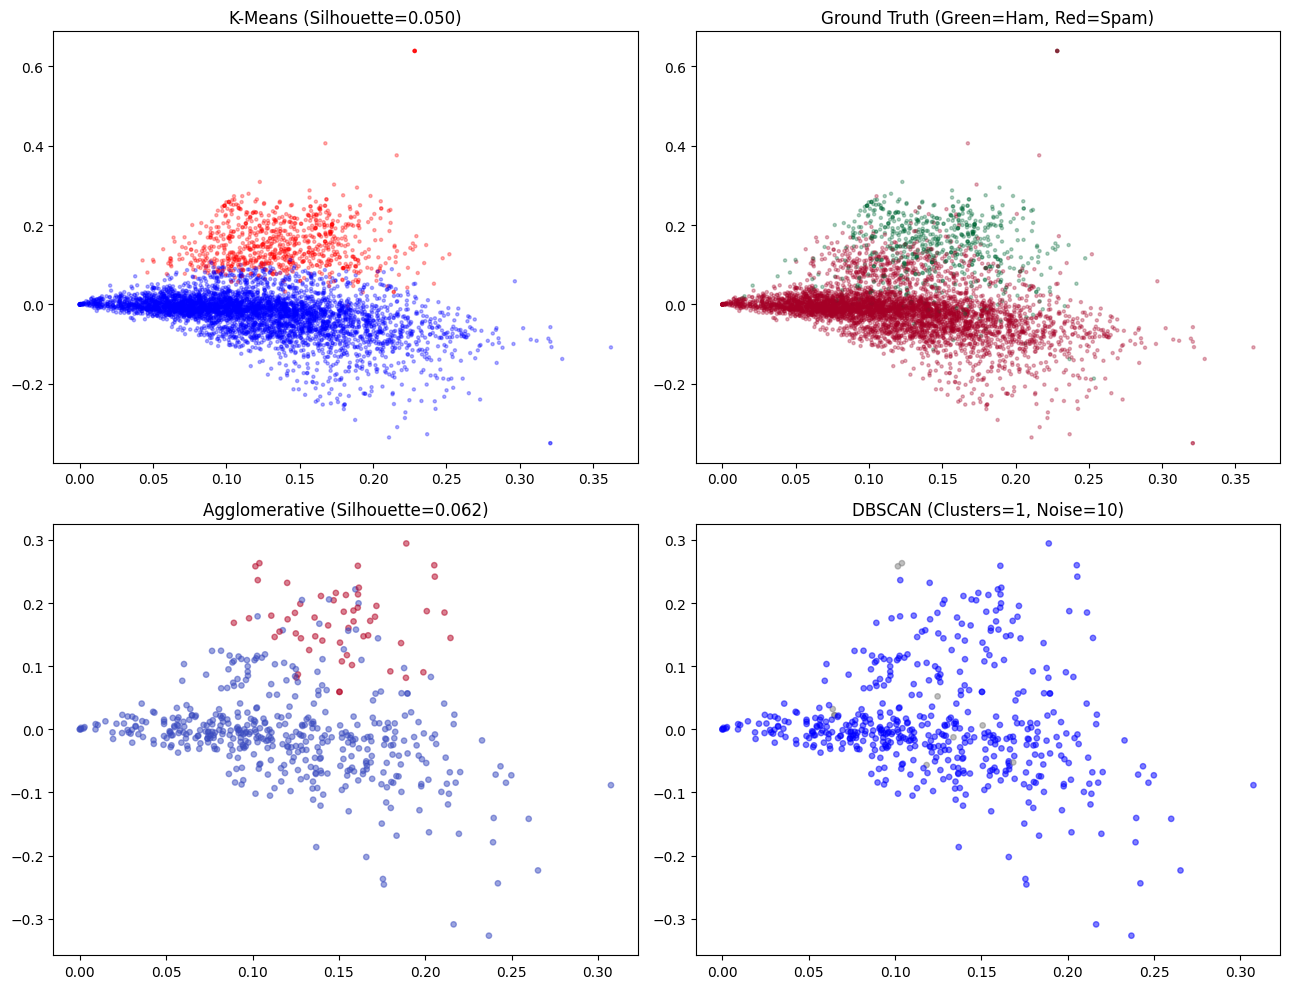

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

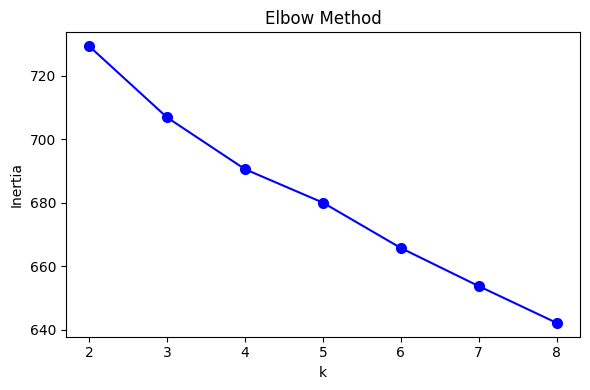

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

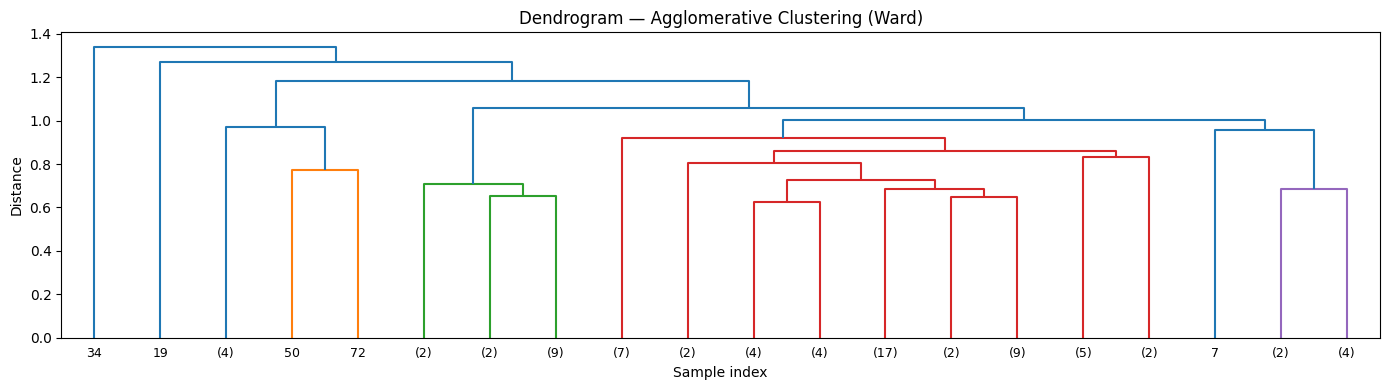

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# 13 — Clustering
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(tfidf.transform(df['clean_text']))

svd2 = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd2.fit_transform(tfidf.transform(df['clean_text']))

K_range = range(2, 9)
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_reduced).inertia_ for k in K_range]

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_reduced)
sil_km = silhouette_score(X_reduced, km_labels, sample_size=1000)
db_km  = davies_bouldin_score(X_reduced, km_labels)
print(f'K-Means  — Silhouette: {sil_km:.4f}  Davies-Bouldin: {db_km:.4f}')

np.random.seed(42)
sample_idx  = np.random.choice(len(X_reduced), 500, replace=False)
X_sample    = X_reduced[sample_idx]
X_2d_sample = X_2d[sample_idx]

agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_labels = agg.fit_predict(X_sample)
sil_agg = silhouette_score(X_sample, agg_labels)
print(f'Agglomerative — Silhouette: {sil_agg:.4f}')

db = DBSCAN(eps=0.5, min_samples=10)
db_labels  = db.fit_predict(X_sample)
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()
print(f'DBSCAN — Clusters: {n_clusters}  Noise: {n_noise}')

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes[0,0].scatter(X_2d[:,0], X_2d[:,1], c=km_labels, cmap='bwr', alpha=0.3, s=5)
axes[0,0].set_title(f'K-Means (Silhouette={sil_km:.3f})')
axes[0,1].scatter(X_2d[:,0], X_2d[:,1], c=df['label_num'].values, cmap='RdYlGn', alpha=0.3, s=5)
axes[0,1].set_title('Ground Truth (Green=Ham, Red=Spam)')
axes[1,0].scatter(X_2d_sample[:,0], X_2d_sample[:,1], c=agg_labels, cmap='coolwarm', alpha=0.5, s=15)
axes[1,0].set_title(f'Agglomerative (Silhouette={sil_agg:.3f})')
colors_db = ['gray' if l == -1 else ('blue' if l == 0 else 'orange') for l in db_labels]
axes[1,1].scatter(X_2d_sample[:,0], X_2d_sample[:,1], c=colors_db, alpha=0.5, s=15)
axes[1,1].set_title(f'DBSCAN (Clusters={n_clusters}, Noise={n_noise})')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(list(K_range), inertias, 'bo-', markersize=7)
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.tight_layout()
plt.show()

np.random.seed(42)
tiny_idx = np.random.choice(len(X_sample), 80, replace=False)
Z = linkage(X_sample[tiny_idx], method='ward')
plt.figure(figsize=(14, 4))
dendrogram(Z, truncate_mode='lastp', p=20,
           leaf_font_size=9, color_threshold=0.7 * max(Z[:, 2]))
plt.title('Dendrogram — Agglomerative Clustering (Ward)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [ ]:
# 14 — Live Spam Predictor
final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   LinearSVC(C=1.0, max_iter=2000, random_state=42))
])
final_pipeline.fit(df['clean_text'], df['label_num'])

def predict_spam(message):
    pred = final_pipeline.predict([preprocess_text(message)])[0]
    return '🚨 SPAM' if pred == 1 else '✅ HAM'

test_messages = [
    "Congratulations! You've won a FREE iPhone. Click here to claim your prize NOW!",
    "Hey, are you coming to the party tonight? Let me know!",
    "URGENT: Your account has been suspended. Call 08001234567 to reactivate.",
    "Can you pick up some milk on your way home?",
    "WIN cash prize of £1000! Text WIN to 87777. T&C apply.",
    "Meeting rescheduled to 3pm tomorrow. See you then."
]

print('=== LIVE SMS SPAM DETECTOR ===')
for msg in test_messages:
    display = msg[:65] + '...' if len(msg) > 65 else msg
    print(f'{predict_spam(msg)} | {display}')

your_msg = "Free entry: Win a brand new car! Text CAR to 50505"
print(f'\nYour message : {your_msg}')
print(f'Result       : {predict_spam(your_msg)}')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== LIVE SMS SPAM DETECTOR ===
🚨 SPAM | Congratulations! You've won a FREE iPhone. Click here to claim yo...
✅ HAM | Hey, are you coming to the party tonight? Let me know!
🚨 SPAM | URGENT: Your account has been suspended. Call 08001234567 to reac...
✅ HAM | Can you pick up some milk on your way home?
🚨 SPAM | WIN cash prize of £1000! Text WIN to 87777. T&C apply.
✅ HAM | Meeting rescheduled to 3pm tomorrow. See you then.

Your message : Free entry: Win a brand new car! Text CAR to 50505
Result       : 🚨 SPAM


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag